In [1]:
import omusic
import omusic.chord as chord
import omusic.modes as modes
from omusic.scale import scale
from omusic import note_i2s
from omusic import note_s2i
from omusic import interval_s2i
from omusic import interval_i2s
from omusic import name_interval
from omusic import invert
from omusic import reach
from omusic import same_class

In [2]:
print(scale("C", modes.MAJOR))
print(scale("C", modes.MINOR_BLUES))
print(scale("C", modes.MAJOR_BLUES))

['C0', 'D0', 'E0', 'F0', 'G0', 'A0', 'B0']
['C0', 'D#0', 'F0', 'F#0', 'G0', 'A#0']
['C0', 'D0', 'D#0', 'E0', 'G0', 'A0']


# Music Theory

## Music Space

There are two pre-defined "music spaces":

* `NOTES_MIDI` represents scientific names where  `NOTES_MIDI[0]` is $\mathrm{C}_{0}$ and `NOTES_MIDI[127]` is $\mathrm{C}_{10}$. Also, `NOTES_MIDI[i]` is the $i^\mathrm{th}$ MIDI sound. This is the default option.

* `NOTES_INTEGER` represents pitch classes, where `NOTES_INTEGER[0]` is $\mathrm{C}$ and `NOTES_INTEGER[11]` is $\mathrm{B}$. Also, `NOTES_MIDI[i]` is the integer notation for that class.

To use a music space, assign the corresponding variable to `omusic.NOTES`.

In [3]:
assert omusic.NOTES == omusic.NOTES_MIDI

For readability, notes are often represented as strings. 


The functions To convert 



(a)
as a string ("C") or (b) as an integer ("0"). 

The following cells define two functions
`note_s2i` and `note_i2s` that convert between
these representations.

In [4]:
for i in range(len(omusic.NOTES)):
    assert note_i2s(i) == omusic.NOTES[i]

Check that `key_s2i` and `key_i2s` are
each others' inverse:

In [5]:
for i in range(len(omusic.NOTES)):
    assert note_i2s(i) == omusic.NOTES[i]

If the name of a note does not end with an octave (`0` to `10`), it is understood to be on the $0^{\mathrm{th}}$ octave. If the octave $o$ is not in range $[0,\cdots,10]$, then it is replaced with $o~(\mathrm{mod}~10)$.

In [6]:
if omusic.NOTES == omusic.NOTES_MIDI:
    assert note_s2i("C") == note_s2i("C0")

In [7]:
from omusic import Pitch, Interval

## Intervals

An **interval** is the musical distance between two notes. An interval between two notes is **harmonic** if these notes are played at the same time; otherwise, the interval is **melodic**. The **half-step** is the smallest apartness commonly used in Western omusic. A **whole-step** equals two half-steps.

In integer notation, an interval be denoted by a simple integer. In text however, intervals are often communicated by name. The following sections explain how these names are formed.

### Generic Intervals

**Generic intervals** measure the difference between the staff positions of two notes. In practice, this measure ignores accidentals: $\mathrm{C}\text{--}\mathrm{D}$ are one genetic step apart, but so are $\mathrm{C}\text{--}\mathrm{D}\#$. This is because $\mathrm{D}$ and $\mathrm{D}\#$ are on the same staff.

Generic intervals, like people, have names. 
For example, $\mathrm{C}\text{--}\mathrm{D}$ are a second apart. The following table lists these names.

|Step difference|Name of Interval|
|-|-|
| 0 | First / Prime |
| 1 | Seconds  |
| 2 | Thrids |
| 3 | Fourths |
| 4 | Fifths |
| 5 | Sixths |
| 6 | Sevens |
| 7 | Eights |

### Specific Intervals

**Specific intervals** are measured on both staff and half steps. For example, recall that $\mathrm{C}\text{--}\mathrm{D}$ are a generic second apart. Because they are also 2 half steps apart, they are a _major second apart_. $\mathrm{B}\text{--}\mathrm{C}$ on the other hand are a _minor second_ apart because they are a genetic second apart while being just one half step apart. Some examples follow:

|Apartness|Name|
|-|-|
| 2 | Major Second |
| 4 | Major Third |
| 5 | Perfect Fourth |
| 7 | Perfect Fifth |
| 9 | Major Sixth |
| 11 | Major Seventh |
| 12 | Perfect Eighth (Perfect octave) |

The terms "major" and "perfect" refer to the interval's quality. Only the 2<sup>nd</sup>s, 3<sup>rd</sup>s, 4<sup>th</sup>s, 6<sup>th</sup>s, and 7<sup>th</sup>s are **major interval**s. The rest (1<sup>st</sup>s, 4<sup>th</sup>s, 5<sup>th</sup>s, and 8<sup>th</sup>s) are **perfect interval**s instead.

A **minor interval** has 1 fewer half step than a major interval. An **augmented interval** has one more than a major interval. An **augmented interval** has one more half step than a perfect interval. A **diminished interval** has one less half step. Minor intervals can be diminished by subtracting yet another half-step. The following figure illustrates these relations:

![image](music_steps.svg)

The following cell seeks to capture this behaviour. In particular:

* `INTERVALS` maps every name of an interval to an apartness (by half steps).

* `apartness_to_name` maps every apartness to a set of names.

* `name_apartness`, when given two notes, returns a probable name for hte interval between them.

Check if the aforementioned intervals are correctly named:

In [8]:
_pairs: list[tuple[str, str]] = [
    ('C#', 'D'),
    ('C', 'D'),
    ('C', 'D#'),
    ('B', 'C'),
]

for __from, to in _pairs:
    print(f"The interval from {__from}"
          f" to {to} is"
          f" {name_interval(__from, to)}")

The interval from C# to D is minor 2
The interval from C to D is major 2
The interval from C to D# is augmented 2
The interval from B to C is minor 2


#### Cheat Sheet

Having suffered through the Library of Alexandria, you have earned yourself access to a cheat sheet. Enjoy :D

In [9]:
persephone: list[tuple[int, str]]\
       = sorted([(b, a) for a, b
                 in omusic.INTERVALS.items()])

import tabulate
tabulate.tabulate((p := persephone,
                  [(*x, *y) for (x, y)
                            in zip(p[:int(len(p)/2)],
                                   p[int(len(p)/2):])])[1],

                  headers=["Half-Step Difference",
                           "Name"]*2,
                  tablefmt="html")

Half-Step Difference,Name,Half-Step Difference,Name
0,augmented 7,5,perfect 4
0,diminished 2,6,augmented 4
0,perfect 8,6,diminished 5
0,prime 1,7,diminished 6
1,augmented 1,7,perfect 5
1,augmented 8,8,augmented 5
1,minor 2,8,minor 6
2,diminished 3,9,diminished 7
2,major 2,9,major 6
3,augmented 2,10,augmented 6


The `reach` function "reaches up" from a given note by either the given apartness (in half steps) of an interval specified by name.

To show the correctness of `reach`, assuming that `name_interval` is correct, try to "reach" from every note to every other note by the name of the interval between them.

In [10]:
for name_x in omusic.NOTE_NAMES:
    for name_y in omusic.NOTE_NAMES:
        same_class(reach(name_x, name_interval(name_x, name_y)), name_y)


### Inverting Intervals

To **invert** a group of notes is to move the lowest note an octave higher. This is easy to implement.

Inverting an interval carries a related meaning. Suppose that inverting C-G gives G-C: _inverting the interval_ between C-G should yield the interval between G-C. The `invert_interval` function captures this behaviour.

Perfect intervals always invert to perfect intervals. A factoid: inverting the perfect 4<sup>th</sup> and the perfect 5<sup>th</sup> give each other.

In [11]:
assert invert(omusic.INTERVALS["perfect 5"])\
           == omusic.INTERVALS["perfect 4"]\
       and invert(omusic.INTERVALS["perfect 4"])\
           == omusic.INTERVALS["perfect 5"]

Reaching "up" from a note by a given interval, then again by the invert of that interval, should produce that note (albeit an octave higher). Together, `reach` and `invert_interval` allows us to test this:

In [12]:
for note, interval in zip(omusic.NOTES,
                          omusic.INTERVALS.values()):
    assert same_class(note,
                      reach(reach(note, interval),
                            invert(interval)))

## Scales

This section is developed with help from _Play Guitar in 14 Days_ by Troy Nelson.

A **scale** is an ordered sequence of notes. In western music, a scale (particularly a _diatonic scale_) is constructed by counting notes from a starting note. This starting note is its **home note** (or _**tonic**_); the pattern of counting is either its key (if the pattern is major or minor) or its mood (if the pattern is, for example, ionian). These inconsistencies are due to historical reasons.


### Scale Degrees 音级

The scale degree is the position of a particular note on a scale, up from the tonic. The $i^\mathrm{th}$ degree can be denoted as $\hat{i}$.

For a heptatonic scale, these degrees have the following names:

| Position | Name |
|-|-|
| 8 | Tonic (again) |
| 7 | Leading Tone / Subtonic |
| 6 | Submediant |
| 5 | Dominant |
| 4 | Subdominant |
| 3 | Mediant |
| 2 | Supertonic |
| 1 | Tonic |

Note some peculiarities: the submediant (6<sup>th</sup>) does not lead into the mediant (3<sup>rd</sup>); rather, it is the "mediant" of the dominant (5<sup>th</sup>) and the subtonic (7<sup>th</sup>).

Also, the 7<sup>th</sup> node can have two names <sub>("may", since some tutorials just call it the supertonic)</sub>: If it is one half step below the tonic, then it is the leading tone; if it is one whole step below the tonic, then it is the subtonic.


### Major and Minor Scales

The **major scale** is a seven-note scale constructed form a specific pattern of half steps and full steps. Here, such patters are represented as a sequence of `2`s and `1`s. The minor scale uses a similar pattern.

{TODO}

For scales, the word **key** can communicate two things: (a) if a scale is major or minor ("the scale is in major key"), or (b) which note is the tonic of the scale ("the scale is in the key of A"). In the latter case, the scale itself is the key. Better not think too hard about it.

### Modes

The adjectives "major" and "minor" can apply to many things, from intervals to keys (modes) to scales. For convenience, this library describes all sequences of intervals as modes. See `omusic.modes` for pre-defined modes.

In [13]:
import omusic.modes as modes

### Constructing Scales

To construct a scale from a tonic and a mode, start counting from the tonic according to the mode. The
`construct_scale` function captures this
behaviour.

In [14]:
scale("C", modes.MINOR_MELODIC)

['C0', 'D0', 'D#0', 'F0', 'G0', 'A0', 'B0']

### Relative Scales

Relative scales contain the same notes, though not arranged in the same order. To build evidence that `construct_scale` is correct, see if it correctly constructs relatives.

Here's every pair of relatives from the circle
of fifthssss. Ssss. Hisssss.

In [15]:
from omusic import same_class, name_interval

CIRCLE_OF_LIFE: list[tuple[str, str]]\
    = [("C", "A"),
       ("G", "E"),
       ("D", "B"),
       ("A", "F#"),
       ("E", "C#"),
       ("B", "G#"),
       ("F#", "D#"),
       ("C#", "A#"),
       ("G#", "F"),
       ("D#", "C"),
       ("A#", "G")]

for major_key, minor_key in CIRCLE_OF_LIFE:
    assert same_class(
        scale(major_key, modes.MAJOR),
        scale(minor_key, modes.MINOR),)
    
    interval_name: str = name_interval(major_key, minor_key)

    print(f"Interval from {major_key} to {minor_key}"
          f" is {name_interval(major_key, minor_key)},"
          f" or {omusic.INTERVALS[interval_name]} half steps.")

Interval from C to A is major 6, or 9 half steps.
Interval from G to E is major 6, or 9 half steps.
Interval from D to B is major 6, or 9 half steps.
Interval from A to F# is major 6, or 9 half steps.
Interval from E to C# is major 6, or 9 half steps.
Interval from B to G# is major 6, or 9 half steps.
Interval from F# to D# is major 6, or 9 half steps.
Interval from C# to A# is major 6, or 9 half steps.
Interval from G# to F is diminished 7, or 9 half steps.
Interval from D# to C is diminished 7, or 9 half steps.
Interval from A# to G is diminished 7, or 9 half steps.


In [16]:
interval_i2s(9)

['major 6', 'diminished 7']

In [17]:
name_interval("A", "G")

'minor 7'

### Pentatonic Scales

A pentatonic scale is a scale with five tones instead of seven. To construct a pentatonic scale from a major heptatonic scale, take items at indices $[1, 2, 3, 5, 6]$ (assuming 1-based indexing). Constructing pentatonic minor scales is similar, but uses indices $[1, 3, 4, 5, 7]$.

The function `pentatonic_major` and 
`pentatonic_minor` capture these behaviours. These
functions can also construct pentatonic scales from other modes.

For convenience, be free to use
`MAJOR_PENTATONIC` and `MINOR_PENTATONIC`.

In [18]:
from omusic.modes import _pentatonic_major
from omusic.modes import _pentatonic_minor

assert modes.MAJOR_PENTATONIC \
    == _pentatonic_major(modes.MAJOR)

assert modes.MINOR_PENTATONIC \
    == _pentatonic_minor(modes.MINOR)

In [19]:
assert same_class(
           scale("C",
               _pentatonic_major(modes.MAJOR)),
           ['C', 'D', 'E', 'G', 'A'])

assert same_class(scale("A",
                       _pentatonic_minor(modes.MINOR)),
           ['A', 'C', 'D', 'E', 'G'])

### Blues Scales

Blues scales are 6-notes long. A blues minor scale is the pentatonic scale with an extra flat 5th. For example, whereas the A pentatonic scale is ['A', 'C', 'D', 'E', 'G'], the A blues scale is ['A', 'C', 'D', 'D#', 'E', 'G'] A blues major scale gets a flat third instead.

In [20]:
from omusic.modes import _blues_major
from omusic.modes import _blues_minor

In [21]:
assert same_class(
    scale('C',
                    _blues_major(modes.MAJOR)),
    ['C', 'D', 'D#', 'E', 'G', 'A'])
assert same_class(
    scale('A',
                    _blues_minor(modes.MINOR)),
    ['A', 'C', 'D', 'D#', 'E', 'G'])

In [22]:
scale("A", modes.MINOR)

['A0', 'B0', 'C1', 'D1', 'E1', 'F1', 'G1']

### Harmonic and Melodic Minors

I see your harmonic minor and raise you
a melodic minor.

The harmonic minor has a 

Recall that the A minor is ['A', 'B', 'C', 'D', 'E', 'F', 'G']. Its harmonic minor is [..., 'E', 'F', 'G#']; its melodic minor is [... 'E', 'F#', 'G#']

In [23]:
from omusic.modes import _harmonic_minor
from omusic.modes import _melodic_minor

In [24]:
assert same_class(
    scale("A", _melodic_minor(modes.MINOR)),
    ['A', 'B', 'C', 'D', 'E', 'F#', 'G#'])

assert same_class(
    scale("A", _harmonic_minor(modes.MINOR)),
    ['A', 'B', 'C', 'D', 'E', 'F', 'G#'])

### Augmented and Diminished Scales

There are two kinds of diminished scales: the
typical whole-half diminished scale (of 
intervals [2, 1, 2, 1, ...]) and the half-whole diminished scale (of intervals [1, 2, 1, 2,...]).


In [25]:
from omusic.modes import DIMINISHED_WHOLE_HALF
from omusic.modes import DIMINISHED_HALF_WHOLE
from omusic.modes import AUGMENTED

In [26]:
assert same_class(
    scale("A", modes.DIMINISHED_HALF_WHOLE),
    ['A', 'A#', 'C', 'C#', 'D#', 'E', 'F#', 'G'])

## Chords

A **chord** is a combination of three or more notes. There are many ways to construct chords, such as constructing triads on a scale.

As you know, a triad is a triple of topological spaces $\{P, A, B\};~A,B\prec P$ where $P=\mathrm{int}(A)\cup\mathrm{int}(B)$.

What you might not know is the fact that the **triad** of a scale is a subset of notes in that scale at the prime, a third, and a fifth. This "prime" is the **root** of the triad.

In [27]:
from omusic.chord import count_triad

A **major triad** takes a major third and a perfect fifth. Other triads are constructed with different choices of thirds and fifths'.

In [28]:
from omusic.chord import count_triad_major

In [29]:
assert same_class(
    count_triad_major("C"),
    ['C', 'E', 'G'])

### Inverting Triads

Like inverting intervals, inverting a triad moves the lowest note up an octave.

When the bass note, the lowest note in the triad, is its root, the triad is in root position. Inverting the triad once moves it into **first inversion**; inverting again moves it to the **second inversion**.

Alternatively, the degree of inversion can be denoted by its bass note. For example, the F major triad is `['F', 'A', 'C']`; its first inversion `['A', 'C', 'F']` can be denoted by F/A.


In [30]:
# invert_triad
# invert_triad_to

### Seventh Chords

A seventh chord combines a triad with an interval of a seventh. There are five types of common seventh chords:

* The dominant seventh uses a major triad and a minor seventh ...

* ... and so on. 

In [31]:
assert omusic.same_class(
    chord.count_seventh_dominant("C"),
    ['C', 'E', 'G', 'A#'])

### Diatonic Triads

Every major and minor scale have seven **diatonic triads**, which are formed from notes on that scale.

The first triad uses the 1<sup>st</sup>, 3<sup>rd</sup>, and 5<sup>th</sup> notes counting up from the root (the root itself being the 1<sup>st</sup>). The n<sup>th</sup> triad instead counts from the n<sup>th</sup> note instead.

In [32]:
from omusic.chord import triad
from omusic.chord import seventh

In [33]:
seventh("C", modes.MAJOR, order=8)

['D1', 'F1', 'A1', 'D2']

Note that this method is identical to the aforementioned approach of counting intervals.

In [34]:
assert chord.count_triad_major("C")\
       == triad("C", modes.MAJOR)

assert chord.count_seventh_augmented_major("C")\
       == seventh("C", modes.AUGMENTED, "major")

#### Roman Numeral Analysis: Seventh Chords

I honestly don't know what this means.

### Neapolitan Chords

To construct a Neapolitan chord, construct a major triad (1, 3, 5) starting with the second scale degree of another scale.



In [35]:
from omusic.chord import neapolitan_chord

In [36]:
neapolitan_chord("A", modes.MAJOR)

['A#0', 'D1', 'F1']

### Nonharmonic Tones

In [37]:
# TEST_SCALES = [
# [MAJOR, "major"],
# [MINOR, "minor"],
# [MINOR_NATURAL, "minor_natural"], 
# [MINOR_HARMONIC, "minor_harmonic"],
# [MINOR_MELODIC, "minor_melodic"],
# [IONIAN, "ionian"],
# [DORIAN, "dorian"],
# [PHRYGIAN, "phrygian"],
# [LYDIAN, "lydian"],
# [MIXOLYDIAN, "mixolydian"],
# [AEOLIAN, "aeolian"],
# [LOCRIAN, "locrian"],]

# list_of_scales = []

# for key in NOTES:
#     for scale in TEST_SCALES:
#         this_scale_set = set(construct_scale(note_s2i(key), scale[0]))
#         that_scale_set = set(note_s2i(["A", "F", "D", "C#", "A#", "G", "B", "C"]))
#         list_of_scales.append([
#             key,
#             scale[1],
#             this_scale_set.intersection(that_scale_set),
#             (this_scale_set.difference(that_scale_set).update(
#                 that_scale_set.difference(this_scale_set)))
#         ])

# list_of_scales.sort(key=lambda x: len(x[2]),
#                     reverse=True)

In [38]:

# for winner in list_of_scales[5:]:
#     print(f"{winner[0]} {winner[1]} has matches {note_i2s(list(winner[2]))}, but not {note_i2s(list(winner[3]))}")

#     # Prog rock -- scales
#     # Two finger picking
#     # Just go faster
#     # Chord transition
#     #   > Major scale harmony
#     #   > Minor scale harmony
#     #   Pentatonic scale - make it easier to 
#     # Figure out songs

# Visualisation

To visualise the fretboard, first find out which notes are on it.


In [39]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

## Drawing the Fretboard

Begin with drawing an empty fretboard.

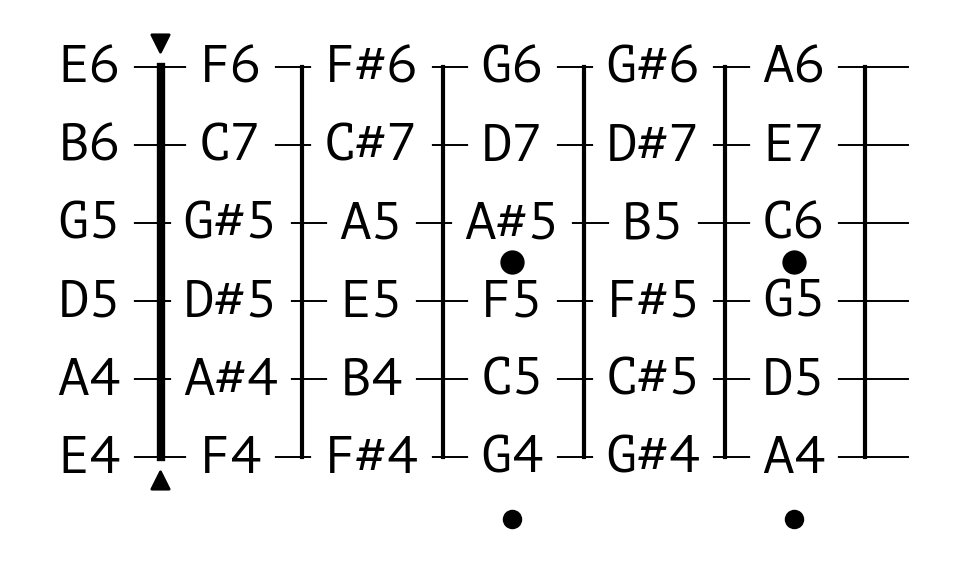

In [40]:
import omusic.guitar as guitar
from omusic.guitar import draw_scale

draw_scale(omusic.NOTES, 0, 6)

In [41]:
triad("C5", modes.MAJOR)

['C5', 'E5', 'G5']

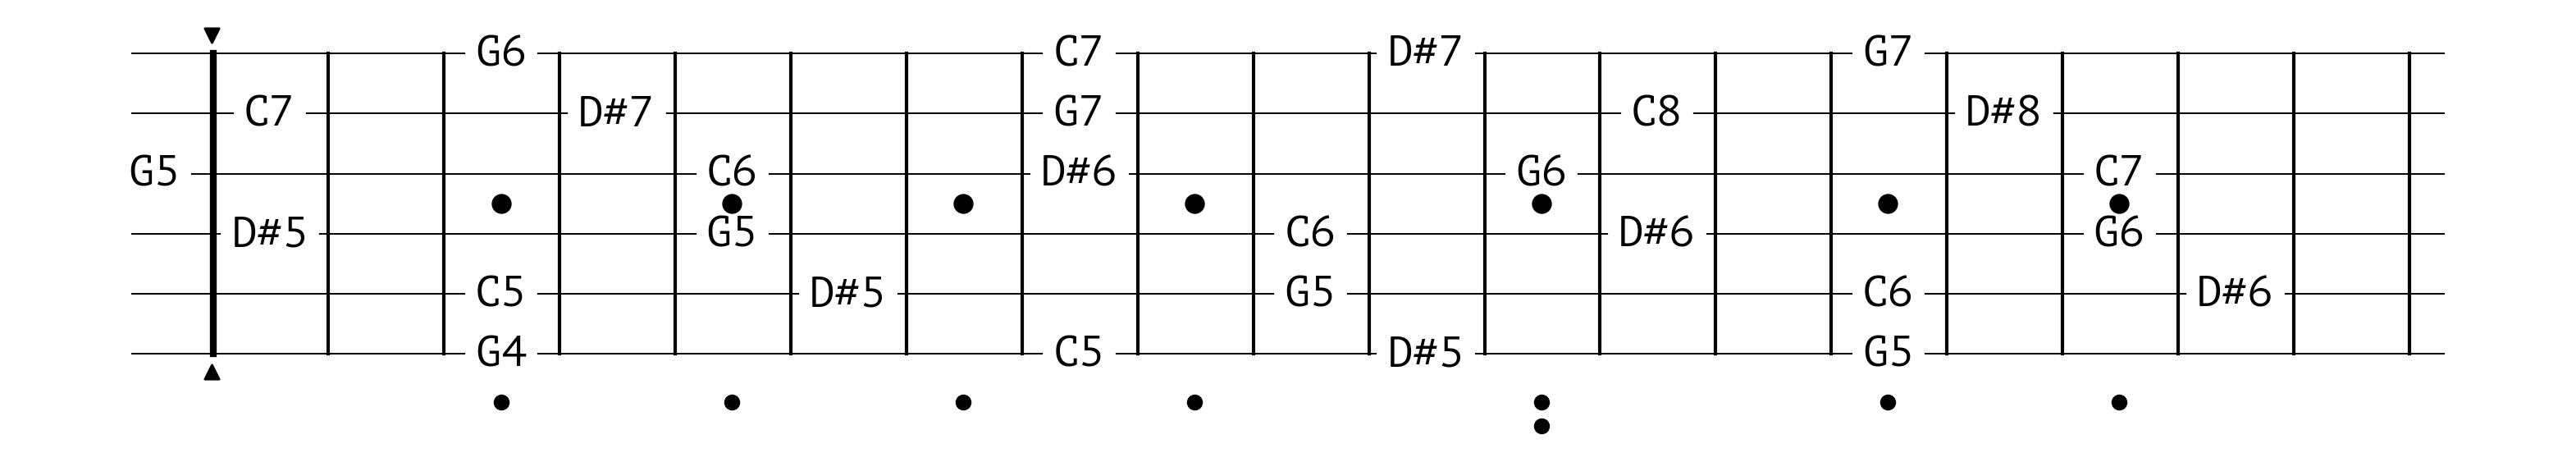

In [42]:
draw_scale(triad("C5", modes.MAJOR_BLUES), 0, 20)

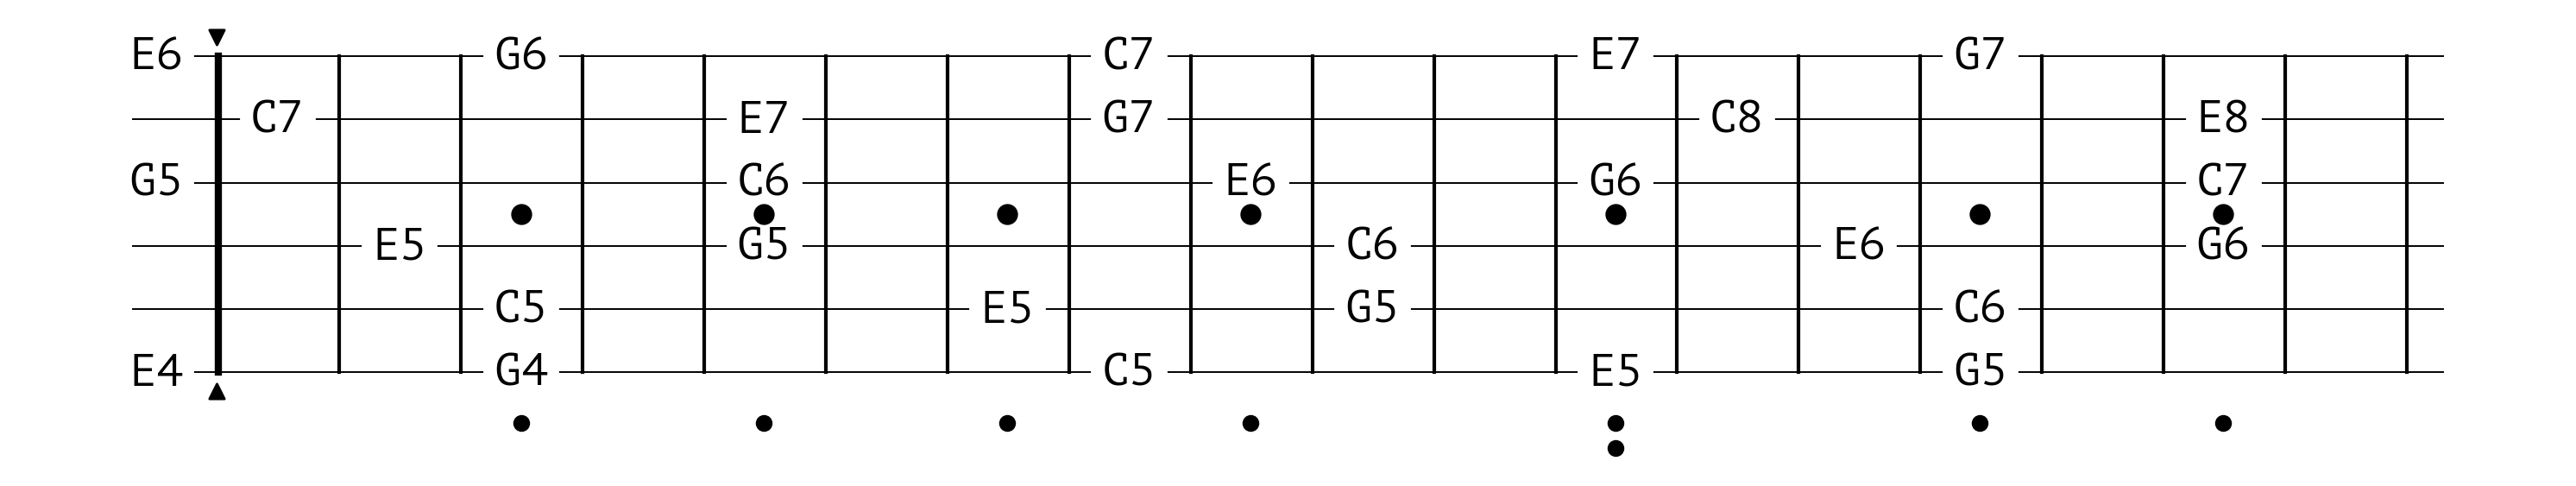

In [43]:
draw_scale(triad("C", modes.MAJOR), 0, 19)

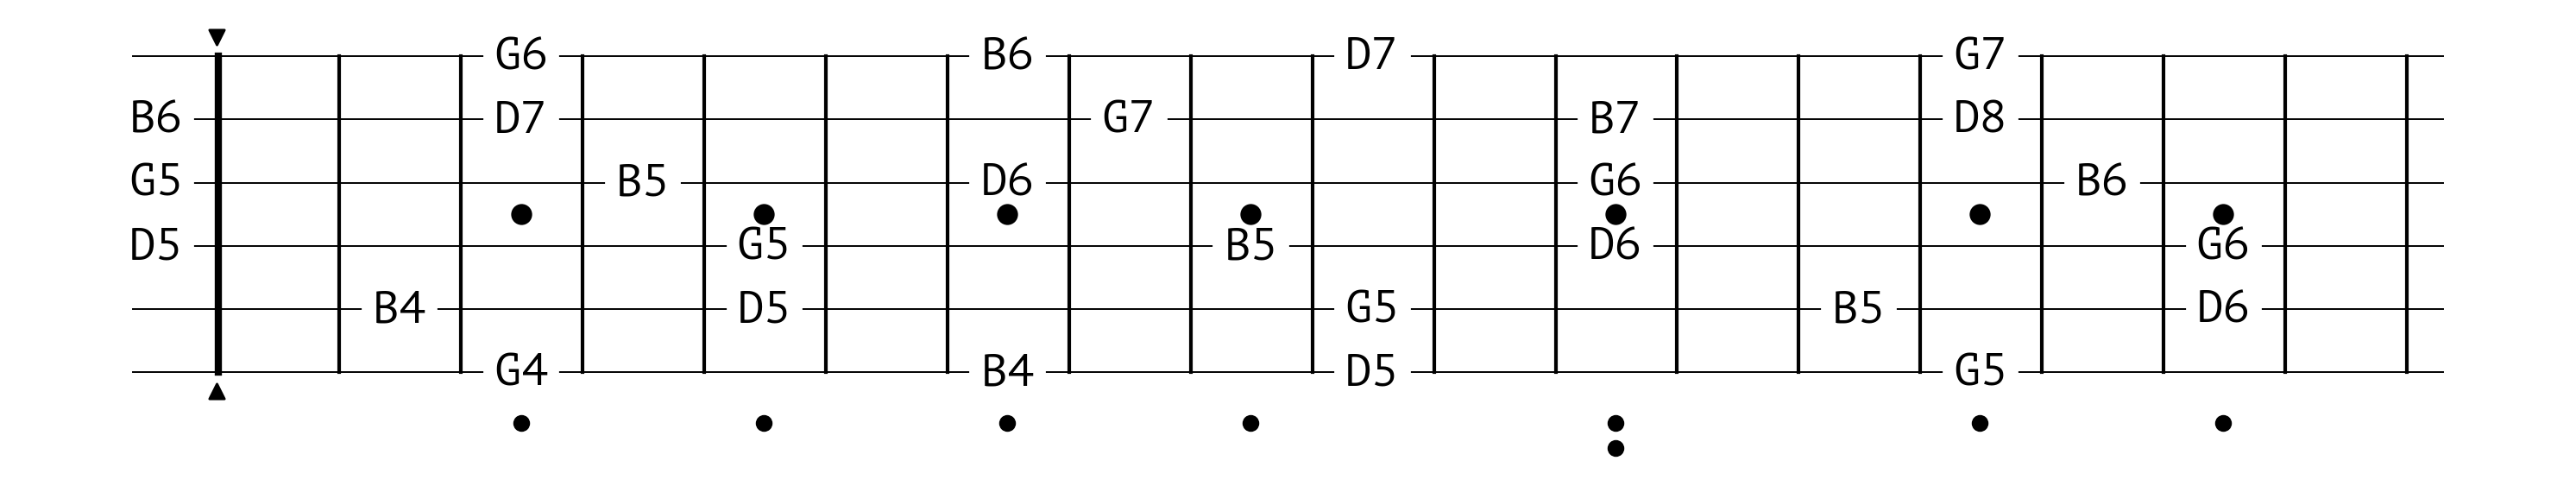

In [44]:
draw_scale(seventh("G4", modes.MAJOR), 0, 19)
# draw_scale(construct_scale("C7", MAJOR), 0, 19)

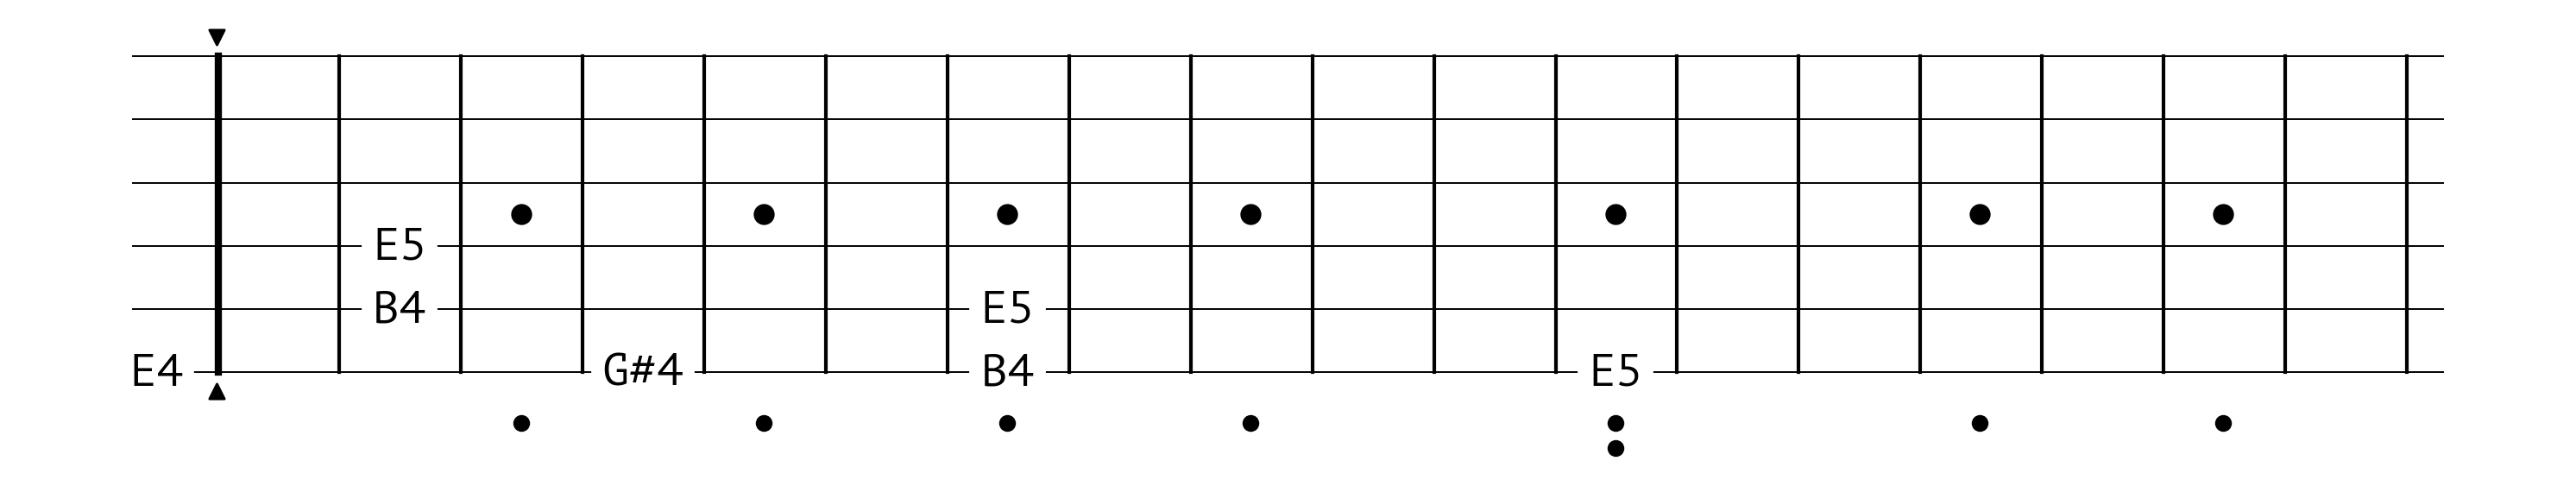

In [ ]:
draw_scale(seventh("E4", modes.MAJOR), 0, 19, strict=True)